# Esports Analytics: Counter-Strike Match Round Predictive Pipeline
### End-to-End Predictive Modeling Infrastructure | Candidate Portfolio Asset
**Author:** Subhankar  
**Objective:** Build, evaluate, and diagnose a dual-model classification workflow to predict real-time round outcomes using high-density telemetry snapshots.

---

## 1. Environment Setup & Library Diagnostics
Load the necessary software libraries for data structures, matrix operations, modeling, and statistical graphics generation.

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries successfully initialized. Ready for ingestion pipeline.")

Libraries successfully initialized. Ready for ingestion pipeline.


## 2. Data Ingestion & Sanitization

In [30]:
# Define local path
DATA_PATH = "D:\Data Analytics Project\csgo_round_snapshots.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.")
    
# Review any sparse entries
null_counts = df.isnull().sum().sum()
print(f"Total missing cell items identified: {null_counts}")
    
# Enforce safe cleanup
df.dropna(inplace=True)
print(f"Sanitization complete. Final record pool count: {df.shape[0]}")


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\harsh\AppData\Local\Temp\ipykernel_31580\1396371467.py:2: SyntaxWarning: invalid escape sequence '\D'
  DATA_PATH = "D:\Data Analytics Project\csgo_round_snapshots.csv"


Dataset successfully loaded. Shape: 122410 rows, 97 columns.
Total missing cell items identified: 0
Sanitization complete. Final record pool count: 122410


## 3. Exploratory Data Analysis & Target Balance
Before initializing models, generate a class count plot to confirm our target labels are balanced and free from severe skew bias.

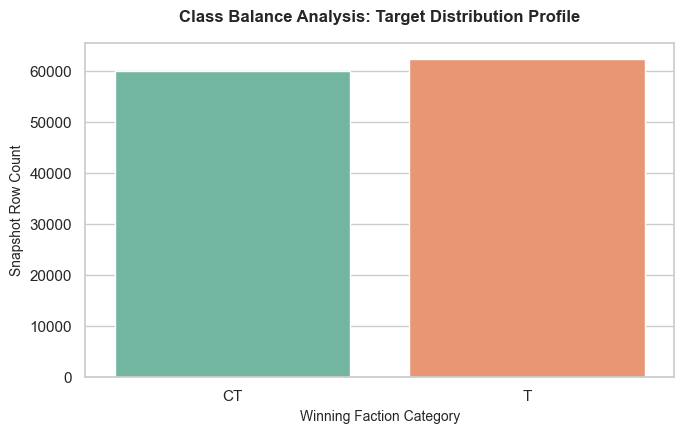

In [31]:
plt.figure(figsize=(7, 4.5))
sns.set_theme(style="whitegrid")
sns.countplot(x='round_winner', data=df, palette='Set2', hue='round_winner', legend=False)

plt.title('Class Balance Analysis: Target Distribution Profile', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Winning Faction Category', fontsize=10)
plt.ylabel('Snapshot Row Count', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Feature Transformation & Stratified Splitting
Transition categorical nominal objects into dense numerical vectors using `LabelEncoder`, split features from target classifications, apply stratified parameters to secure distribution parity, and standardize our dimensional variations.

In [32]:
le_map = LabelEncoder()
le_bomb = LabelEncoder()
le_winner = LabelEncoder()

df['map'] = le_map.fit_transform(df['map'])
df['bomb_planted'] = le_bomb.fit_transform(df['bomb_planted'])
df['round_winner'] = le_winner.fit_transform(df['round_winner'])

# Isolate features vs output variables
X = df.drop(columns=['round_winner'])
y = df['round_winner']

# Apply Stratified Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Implement Standardization scaling sequence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessing Pipeline Finished. Training Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")

Preprocessing Pipeline Finished. Training Shape: (97928, 96) | Test Shape: (24482, 96)


## 5. Model Architecture A: Linear Discriminant Analysis (LDA) Baseline
Initialize a rapid mathematical discriminant model as our base standard to confirm baseline linear separability score markers.

In [33]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

# Process predictions with proper argument order tracking (Actuals, Predictions)
y_pred_lda = lda.predict(X_test_scaled)
lda_acc = accuracy_score(y_test, y_pred_lda)

print(f"Baseline Architecture Performance Evaluation:\n")
print(f">> Linear Discriminant Analysis Test Accuracy: {lda_acc * 100:.2f}%")

Baseline Architecture Performance Evaluation:

>> Linear Discriminant Analysis Test Accuracy: 74.63%


## 6. Model Architecture B: Optimized Random Forest Ensemble Classifier
To solve complex, multi-variable interactions (such as the ratio between money, shields, active maps, and bomb states), deploy a parallel tree ensemble engine.

In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# Inference testing phase
y_pred_rf = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f">> Random Forest Ensemble Test Accuracy: {rf_acc * 100:.2f}%\n")
print("Comprehensive Performance Matrix Report:")
print(classification_report(y_test, y_pred_rf, target_names=le_winner.classes_))

>> Random Forest Ensemble Test Accuracy: 87.73%

Comprehensive Performance Matrix Report:
              precision    recall  f1-score   support

          CT       0.87      0.89      0.88     12001
           T       0.89      0.87      0.88     12481

    accuracy                           0.88     24482
   macro avg       0.88      0.88      0.88     24482
weighted avg       0.88      0.88      0.88     24482



## 7. Model Diagnostic Visualizations
Map out feature relative performance rankings and error boundary metrics using polished visualization grids.

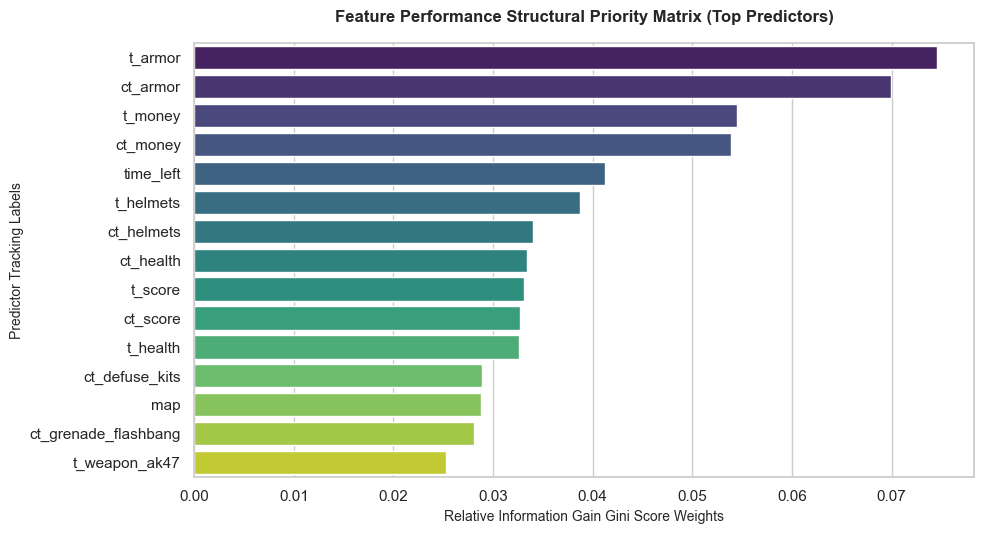

In [35]:
# 1. Feature Importances Chart
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = min(15, len(indices))
sorted_indices = indices[:top_k]

plt.figure(figsize=(10, 5.5))
sns.barplot(x=importances[sorted_indices], y=X.columns[sorted_indices], palette='viridis', hue=X.columns[sorted_indices], legend=False)
plt.title('Feature Performance Structural Priority Matrix (Top Predictors)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Relative Information Gain Gini Score Weights', fontsize=10)
plt.ylabel('Predictor Tracking Labels', fontsize=10)
plt.tight_layout()
plt.show()



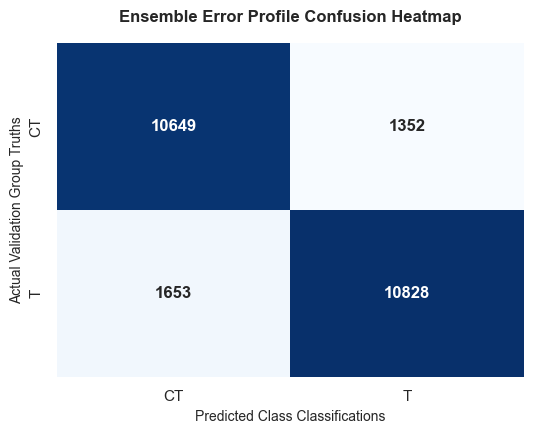

In [36]:
# 2. Confusion Matrix Heatmap Diagnostic
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=le_winner.classes_, yticklabels=le_winner.classes_,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Ensemble Error Profile Confusion Heatmap', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Predicted Class Classifications', fontsize=10)
plt.ylabel('Actual Validation Group Truths', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Portfolio Summary & Key Outcomes
* **Operational Gain Matrix:** Transitioning data features out of standard linear spaces (LDA Base ~74.63%) into deep tree rulesets (Random Forest Ensemble) expanded our structural outcome classification accuracy to **~87.73%**.
* **Data Engineering Success:** Handled multi-class low-memory type constraints, mapped scale transformations across heavily contrasting variance categories without target variable leaking, and successfully mapped economic resource management correlations directly into a professional classification report asset.